<a href="https://colab.research.google.com/github/CYBERCONQUEROR/PHD-Project/blob/main/NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.preprocessing import LabelEncoder

# Download once
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Load dataset
df = pd.read_csv(r"/content/Hugging_face text.csv")

# Drop unwanted column
df.drop(columns=['Unnamed: 0'], inplace=True)

# Initialize tools
stop_words = set(stopwords.words('english'))
# lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()                               # Lowercase
    text = re.sub(r'[^a-z\s]', '', text)              # Remove punctuation & numbers
    tokens = text.split()                             # Tokenization
    tokens = [word for word in tokens if word not in stop_words]
    # tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(tokens)

# Handle missing values in 'statement' column by filling with empty strings
df['statement'] = df['statement'].fillna('')

# Apply preprocessing
df['clean_text'] = df['statement'].apply(preprocess_text)


# Encode labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['status'])

print(df.head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


                                           statement   status  \
0                                         oh my gosh  Anxiety   
1  trouble sleeping, confused mind, restless hear...  Anxiety   
2  All wrong, back off dear, forward doubt. Stay ...  Anxiety   
3  I've shifted my focus to something else but I'...  Anxiety   
4  I'm restless and restless, it's been a month n...  Anxiety   

                                          clean_text  label  
0                                            oh gosh      0  
1  trouble sleeping confused mind restless heart ...      0  
2  wrong back dear forward doubt stay restless re...      0  
3  ive shifted focus something else im still worried      0  
4                im restless restless month boy mean      0  


In [10]:
df['clean_text']

,clean_text
0,oh gosh
1,trouble sleeping confused mind restless heart ...
2,wrong back dear forward doubt stay restless re...
3,ive shifted focus something else im still worried
4,im restless restless month boy mean
...,...
53038,nobody takes seriously ive dealt depressionanx...
53039,selfishness dont feel good like dont belong wo...
53040,way sleep better cant sleep nights meds didnt ...
53041,public speaking tips hi give presentation work...


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   statement   53043 non-null  object
 1   status      53043 non-null  object
 2   clean_text  53043 non-null  object
 3   label       53043 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 1.6+ MB


In [12]:
df.to_csv("preprocessed_dataset.csv", index=False)


**CNN+BILSTM+ATTENTION**

In [5]:
# ==============================
# 1️⃣ IMPORTS
# ==============================
import time
import torch
import torch.nn as nn
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ==============================
# 2️⃣ LOAD DATASET
# ==============================
df = pd.read_csv("/content/preprocessed_dataset.csv")
df['clean_text'] = df['clean_text'].astype(str)

# ==============================
# 3️⃣ TOKENIZATION
# ==============================
MODEL_NAME = "bert-base-uncased"
MAX_LEN = 128

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

def tokenize_data(texts):
    return tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )

encodings = tokenize_data(df['clean_text'])
labels = torch.tensor(df['label'].values)

# ==============================
# 4️⃣ TRAIN–VALIDATION SPLIT
# ==============================

train_idx, val_idx = train_test_split(
    range(len(labels)),
    test_size=0.2,
    random_state=42,
    stratify=labels
)

train_encodings = {k: v[train_idx] for k, v in encodings.items()}
val_encodings   = {k: v[val_idx] for k, v in encodings.items()}

train_labels = labels[train_idx]
val_labels   = labels[val_idx]

# ==============================
# 5️⃣ DATASET CLASS
# ==============================
class TextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = TextDataset(train_encodings, train_labels)
val_dataset   = TextDataset(val_encodings, val_labels)

# ==============================
# 1️⃣ NEW: ATTENTION LAYER CLASS
# ==============================
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super(Attention, self).__init__()
        # Linear layer to compute the attention weights
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, lstm_output):
        # lstm_output shape: (batch, seq_len, hidden_dim)

        # Calculate attention scores
        attn_weights = self.attn(lstm_output) # (batch, seq_len, 1)
        attn_weights = torch.softmax(attn_weights, dim=1)

        # Multiply weights by original LSTM output
        # (batch, seq_len, hidden_dim) * (batch, seq_len, 1)
        context = torch.sum(attn_weights * lstm_output, dim=1)

        return context, attn_weights

# ==============================
# 2️⃣ UPDATED MODEL: CNN + BiLSTM + ATTENTION
# ==============================
class CNN_BiLSTM_Attention(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.conv = nn.Conv1d(
            in_channels=embed_dim,
            out_channels=128,
            kernel_size=3,
            padding=1
        )

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2)

        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=128,
            bidirectional=True,
            batch_first=True
        )

        # New Attention Layer
        # hidden_size is 128 * 2 because the LSTM is bidirectional
        self.attention = Attention(256)

        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, input_ids, attention_mask=None):
        x = self.embedding(input_ids)  # (batch, seq_len, embed_dim)
        x = x.permute(0, 2, 1)         # (batch, embed_dim, seq_len)

        x = self.conv(x)
        x = self.relu(x)
        x = self.pool(x)

        x = x.permute(0, 2, 1)         # (batch, new_seq_len, 128)

        lstm_out, _ = self.lstm(x)     # (batch, new_seq_len, 256)

        # 🔥 CHANGE: Use Attention instead of [:, -1, :]
        attn_out, weights = self.attention(lstm_out)

        out = self.dropout(attn_out)
        return self.fc(out)
# ==============================
# 7️⃣ DEVICE INFO
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\n🔍 Device Information")
print(f"🖥️ Device in use: {device}")

if device.type == "cuda":
    print(f"🚀 GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ GPU not detected, using CPU")

# ==============================
# 8️⃣ INITIALIZE MODEL
# ==============================
vocab_size = tokenizer.vocab_size
embed_dim = 300
num_classes = len(df['label'].unique())

model = CNN_BiLSTM_Attention(vocab_size, embed_dim, num_classes)
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3
)
# scheduler.step(val_accs)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)

# ==============================
# 9️⃣ TRAINING LOOP WITH EARLY STOPPING
# ==============================
EPOCHS = 30            # max epochs
patience = 10          # early stopping patience
best_val_acc = 0
epochs_no_improve = 0

train_losses, val_losses = [], []
train_accs_list, val_accs_list = [], [] # Renamed to avoid confusion with single epoch accuracy

training_start_time = time.time()
print("\n🚀 Training started with Early Stopping...\n")

for epoch in range(EPOCHS):
    epoch_start_time = time.time()

    # ===== TRAIN =====
    model.train()
    train_total_loss = 0 # Initialize total_loss for training
    preds, true = [], []

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        labels_batch = batch["labels"].to(device)

        outputs = model(input_ids, None)
        loss = criterion(outputs, labels_batch)

        loss.backward()
        optimizer.step()

        train_total_loss += loss.item() # Accumulate training loss
        preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
        true.extend(labels_batch.cpu().numpy())

    train_acc = accuracy_score(true, preds)
    train_losses.append(train_total_loss / len(train_loader))
    train_accs_list.append(train_acc) # Append single epoch accuracy to list

    # ===== VALIDATION =====
    model.eval()
    val_total_loss = 0 # Initialize total_loss for validation
    preds, true = [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            labels_batch = batch["labels"].to(device)

            outputs = model(input_ids, None)
            loss = criterion(outputs, labels_batch)

            val_total_loss += loss.item() # Accumulate validation loss
            preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            true.extend(labels_batch.cpu().numpy())

    val_acc = accuracy_score(true, preds)
    val_losses.append(val_total_loss / len(val_loader))
    val_accs_list.append(val_acc) # Append single epoch accuracy to list

    epoch_time = time.time() - epoch_start_time

    print(
        f"📘 Epoch {epoch+1} | "
        f"⏱️ {epoch_time:.2f}s | "
        f"📈 Train Acc: {train_acc:.4f} | "
        f"✅ Val Acc: {val_acc:.4f}"
    )

    # ===== EARLY STOPPING LOGIC =====
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model.pth")
        print("💾 Best model saved!\n")
    else:
        epochs_no_improve += 1
        print(f"⚠️ No improvement for {epochs_no_improve} epoch(s)\n")

    if epochs_no_improve >= patience:
        print("🛑 Early stopping triggered!")
        break

# ==============================
# 🔟 TOTAL TRAINING TIME
# ==============================
total_time = time.time() - training_start_time

print("\n🎉 Training completed!")
print(f"🏆 Best Validation Accuracy: {best_val_acc:.4f}")
print(f"⏳ Total training time: {total_time/60:.2f} minutes")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


🔍 Device Information
🖥️ Device in use: cuda
🚀 GPU Name: Tesla T4

🚀 Training started with Early Stopping...

📘 Epoch 1 | ⏱️ 12.84s | 📈 Train Acc: 0.6397 | ✅ Val Acc: 0.7199
💾 Best model saved!

📘 Epoch 2 | ⏱️ 11.10s | 📈 Train Acc: 0.7532 | ✅ Val Acc: 0.7461
💾 Best model saved!

📘 Epoch 3 | ⏱️ 11.08s | 📈 Train Acc: 0.7925 | ✅ Val Acc: 0.7582
💾 Best model saved!

📘 Epoch 4 | ⏱️ 11.28s | 📈 Train Acc: 0.8212 | ✅ Val Acc: 0.7664
💾 Best model saved!

📘 Epoch 5 | ⏱️ 11.28s | 📈 Train Acc: 0.8517 | ✅ Val Acc: 0.7304
⚠️ No improvement for 1 epoch(s)

📘 Epoch 6 | ⏱️ 11.23s | 📈 Train Acc: 0.8747 | ✅ Val Acc: 0.7619
⚠️ No improvement for 2 epoch(s)

📘 Epoch 7 | ⏱️ 11.37s | 📈 Train Acc: 0.8989 | ✅ Val Acc: 0.7584
⚠️ No improvement for 3 epoch(s)

📘 Epoch 8 | ⏱️ 11.37s | 📈 Train Acc: 0.9196 | ✅ Val Acc: 0.7562
⚠️ No improvement for 4 epoch(s)

📘 Epoch 9 | ⏱️ 11.34s | 📈 Train Acc: 0.9366 | ✅ Val Acc: 0.7520
⚠️ No improvement for 5 epoch(s)

📘 Epoch 10 | ⏱️ 11.46s | 📈 Train Acc: 0.9506 | ✅ Val Acc: 0.

In [9]:
!pip install torchinfo

from torchinfo import summary

dummy_input_ids = torch.randint(0, vocab_size, (1, MAX_LEN)).to(device)
dummy_mask = torch.ones((1, MAX_LEN)).to(device)

summary(model, input_data=(dummy_input_ids, dummy_mask))

Layer (type:depth-idx)                   Output Shape              Param #
CNN_BiLSTM_Attention                     [1, 7]                    --
├─Embedding: 1-1                         [1, 128, 300]             9,156,600
├─Conv1d: 1-2                            [1, 128, 128]             115,328
├─ReLU: 1-3                              [1, 128, 128]             --
├─MaxPool1d: 1-4                         [1, 128, 64]              --
├─LSTM: 1-5                              [1, 64, 256]              264,192
├─Attention: 1-6                         [1, 256]                  --
│    └─Linear: 2-1                       [1, 64, 1]                257
├─Dropout: 1-7                           [1, 256]                  --
├─Linear: 1-8                            [1, 7]                    1,799
Total params: 9,538,176
Trainable params: 9,538,176
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 40.83
Input size (MB): 0.00
Forward/backward pass size (MB): 0.57
Params size (MB): 38.15
Est

In [ ]:
# ==============================
# 1️⃣1️⃣ SAVE MODEL & TOKENIZER
# ==============================
import os

# Create a folder to store artifacts if it doesn't exist
save_path = "saved_model_assets"
if not os.path.exists(save_path):
    os.makedirs(save_path)

# 1. Save the Model Weights
# (Note: 'best_model.pth' is already saved inside your training loop,
# but let's move it to our specific folder)
model_file = os.path.join(save_path, "best_model.pth")
torch.save(model.state_dict(), model_file)

# 2. Save the Tokenizer
# This saves vocab.txt, tokenizer_config.json, etc.
tokenizer.save_pretrained(save_path)

print(f"\n✅ All assets saved to: {save_path}")
print(f"📦 Files created: {os.listdir(save_path)}")


✅ All assets saved to: saved_model_assets
📦 Files created: ['tokenizer.json', 'best_model.pth', 'tokenizer_config.json']


**CNN+BILSTM**

In [10]:
# ==============================
# 1️⃣ IMPORTS
# ==============================
import time
import torch
import torch.nn as nn
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ==============================
# 2️⃣ LOAD DATASET
# ==============================
df = pd.read_csv("/content/preprocessed_dataset.csv")
df['clean_text'] = df['clean_text'].astype(str)

# ==============================
# 3️⃣ TOKENIZATION
# ==============================
MODEL_NAME = "bert-base-uncased"
MAX_LEN = 128

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

def tokenize_data(texts):
    return tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )

encodings = tokenize_data(df['clean_text'])
labels = torch.tensor(df['label'].values)

# ==============================
# 4️⃣ TRAIN–VALIDATION SPLIT
# ==============================

train_idx, val_idx = train_test_split(
    range(len(labels)),
    test_size=0.2,
    random_state=42,
    stratify=labels
)
# train_idx, val_idx = train_test_split(
#     range(len(labels)), test_size=0.2, random_state=42
# )

train_encodings = {k: v[train_idx] for k, v in encodings.items()}
val_encodings   = {k: v[val_idx] for k, v in encodings.items()}

train_labels = labels[train_idx]
val_labels   = labels[val_idx]

# ==============================
# 5️⃣ DATASET CLASS
# ==============================
class TextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = TextDataset(train_encodings, train_labels)
val_dataset   = TextDataset(val_encodings, val_labels)

# ==============================
# 6️⃣ MODEL: CNN + BiLSTM
# ==============================

class CNN_BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.conv = nn.Conv1d(
            in_channels=embed_dim,
            out_channels=128,
            kernel_size=3,
            padding=1
        )

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2)

        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=128,
            bidirectional=True,
            batch_first=True
        )

        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, input_ids, attention_mask):

        x = self.embedding(input_ids)  # (batch, seq_len, embed_dim)

        x = x.permute(0, 2, 1)  # (batch, embed_dim, seq_len)

        x = self.conv(x)
        x = self.relu(x)
        x = self.pool(x)

        x = x.permute(0, 2, 1)  # (batch, seq_len, features)

        lstm_out, _ = self.lstm(x)

        out = lstm_out[:, -1, :]  # last timestep

        out = self.dropout(out)

        return self.fc(out)


# ==============================
# 7️⃣ DEVICE INFO
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\n🔍 Device Information")
print(f"🖥️ Device in use: {device}")

if device.type == "cuda":
    print(f"🚀 GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ GPU not detected, using CPU")

# ==============================
# 8️⃣ INITIALIZE MODEL
# ==============================
vocab_size = tokenizer.vocab_size
embed_dim = 300
num_classes = len(df['label'].unique())

model = CNN_BiLSTM(vocab_size, embed_dim, num_classes)
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3
)
# scheduler.step(val_accs)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)

# ==============================
# 9️⃣ TRAINING LOOP WITH EARLY STOPPING
# ==============================
EPOCHS = 30            # max epochs
patience = 10          # early stopping patience
best_val_acc = 0
epochs_no_improve = 0

train_losses, val_losses = [], []
train_accs_list, val_accs_list = [], [] # Renamed to avoid confusion with single epoch accuracy

training_start_time = time.time()
print("\n🚀 Training started with Early Stopping...\n")

for epoch in range(EPOCHS):
    epoch_start_time = time.time()

    # ===== TRAIN =====
    model.train()
    train_total_loss = 0 # Initialize total_loss for training
    preds, true = [], []

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        labels_batch = batch["labels"].to(device)

        outputs = model(input_ids, None)
        loss = criterion(outputs, labels_batch)

        loss.backward()
        optimizer.step()

        train_total_loss += loss.item() # Accumulate training loss
        preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
        true.extend(labels_batch.cpu().numpy())

    train_acc = accuracy_score(true, preds)
    train_losses.append(train_total_loss / len(train_loader))
    train_accs_list.append(train_acc) # Append single epoch accuracy to list

    # ===== VALIDATION =====
    model.eval()
    val_total_loss = 0 # Initialize total_loss for validation
    preds, true = [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            labels_batch = batch["labels"].to(device)

            outputs = model(input_ids, None)
            loss = criterion(outputs, labels_batch)

            val_total_loss += loss.item() # Accumulate validation loss
            preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            true.extend(labels_batch.cpu().numpy())

    val_acc = accuracy_score(true, preds)
    val_losses.append(val_total_loss / len(val_loader))
    val_accs_list.append(val_acc) # Append single epoch accuracy to list

    epoch_time = time.time() - epoch_start_time

    print(
        f"📘 Epoch {epoch+1} | "
        f"⏱️ {epoch_time:.2f}s | "
        f"📈 Train Acc: {train_acc:.4f} | "
        f"✅ Val Acc: {val_acc:.4f}"
    )

    # ===== EARLY STOPPING LOGIC =====
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model.pth")
        print("💾 Best model saved!\n")
    else:
        epochs_no_improve += 1
        print(f"⚠️ No improvement for {epochs_no_improve} epoch(s)\n")

    if epochs_no_improve >= patience:
        print("🛑 Early stopping triggered!")
        break

# ==============================
# 🔟 TOTAL TRAINING TIME
# ==============================
total_time = time.time() - training_start_time

print("\n🎉 Training completed!")
print(f"🏆 Best Validation Accuracy: {best_val_acc:.4f}")
print(f"⏳ Total training time: {total_time/60:.2f} minutes")


🔍 Device Information
🖥️ Device in use: cuda
🚀 GPU Name: Tesla T4

🚀 Training started with Early Stopping...

📘 Epoch 1 | ⏱️ 11.11s | 📈 Train Acc: 0.5354 | ✅ Val Acc: 0.5899
💾 Best model saved!

📘 Epoch 2 | ⏱️ 11.23s | 📈 Train Acc: 0.6233 | ✅ Val Acc: 0.6516
💾 Best model saved!

📘 Epoch 3 | ⏱️ 12.22s | 📈 Train Acc: 0.6960 | ✅ Val Acc: 0.6897
💾 Best model saved!

📘 Epoch 4 | ⏱️ 15.14s | 📈 Train Acc: 0.7540 | ✅ Val Acc: 0.7278
💾 Best model saved!

📘 Epoch 5 | ⏱️ 15.68s | 📈 Train Acc: 0.7977 | ✅ Val Acc: 0.7152
⚠️ No improvement for 1 epoch(s)

📘 Epoch 6 | ⏱️ 17.40s | 📈 Train Acc: 0.8269 | ✅ Val Acc: 0.7448
💾 Best model saved!

📘 Epoch 7 | ⏱️ 14.46s | 📈 Train Acc: 0.8554 | ✅ Val Acc: 0.7435
⚠️ No improvement for 1 epoch(s)

📘 Epoch 8 | ⏱️ 11.09s | 📈 Train Acc: 0.8829 | ✅ Val Acc: 0.7445
⚠️ No improvement for 2 epoch(s)

📘 Epoch 9 | ⏱️ 10.91s | 📈 Train Acc: 0.9016 | ✅ Val Acc: 0.7403
⚠️ No improvement for 3 epoch(s)

📘 Epoch 10 | ⏱️ 10.95s | 📈 Train Acc: 0.9180 | ✅ Val Acc: 0.7429
⚠️ No im

In [13]:
# ==============================
# 1️⃣ IMPORTS
# ==============================
import time
import torch
import torch.nn as nn
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import BertModel, BertTokenizer # Import BertModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ==============================
# 2️⃣ LOAD DATASET (reusing from previous cells)
# ==============================
df = pd.read_csv("/content/preprocessed_dataset.csv")
df['clean_text'] = df['clean_text'].astype(str)

# ==============================
# 3️⃣ TOKENIZATION (reusing from previous cells)
# ==============================
MODEL_NAME = "bert-base-uncased"
MAX_LEN = 128

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

def tokenize_data(texts):
    return tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )

encodings = tokenize_data(df['clean_text'])
labels = torch.tensor(df['label'].values)

# ==============================
# 4️⃣ TRAIN–VALIDATION SPLIT (reusing from previous cells)
# ==============================
train_idx, val_idx = train_test_split(
    range(len(labels)),
    test_size=0.2,
    random_state=42,
    stratify=labels
)

train_encodings = {k: v[train_idx] for k, v in encodings.items()}
val_encodings   = {k: v[val_idx] for k, v in encodings.items()}

train_labels = labels[train_idx]
val_labels   = labels[val_idx]

# ==============================
# 5️⃣ DATASET CLASS (reusing from previous cells)
# ==============================
class TextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = TextDataset(train_encodings, train_labels)
val_dataset   = TextDataset(val_encodings, val_labels)

# ==============================
# 6️⃣ NEW MODEL: BERT + BiLSTM
# ==============================
class BERT_BiLSTM(nn.Module):
    def __init__(self, num_classes, dropout_prob=0.5):
        super(BERT_BiLSTM, self).__init__()
        # Load pre-trained BERT model
        self.bert = BertModel.from_pretrained(MODEL_NAME)

        # Freeze BERT layers (optional, but common for feature extraction)
        # for param in self.bert.parameters():
        #     param.requires_grad = False

        # BiLSTM layer, input size is BERT's hidden size
        self.lstm = nn.LSTM(
            input_size=self.bert.config.hidden_size, # Typically 768 for bert-base-uncased
            hidden_size=128, # Hidden size for each direction of LSTM
            bidirectional=True,
            batch_first=True # Input and output tensors are provided as (batch, seq, feature)
        )

        self.dropout = nn.Dropout(dropout_prob)
        # Linear layer for classification, input size is 128 * 2 (for bidirectional LSTM)
        self.fc = nn.Linear(128 * 2, num_classes)

    def forward(self, input_ids, attention_mask):
        # Get BERT embeddings
        # outputs.last_hidden_state: (batch_size, sequence_length, hidden_size)
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state

        # Pass through BiLSTM
        # lstm_out: (batch_size, sequence_length, hidden_size * num_directions)
        # hidden: (num_layers * num_directions, batch_size, hidden_size)
        # cell: (num_layers * num_directions, batch_size, hidden_size)
        lstm_out, (hidden, cell) = self.lstm(sequence_output)

        # Concatenate the last hidden states of the forward and backward LSTMs
        # hidden[-2, :, :] is the last hidden state of the forward LSTM
        # hidden[-1, :, :] is the last hidden state of the backward LSTM
        combined_hidden = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)

        out = self.dropout(combined_hidden)
        return self.fc(out)

# ==============================
# 7️⃣ DEVICE INFO (reusing from previous cells)
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\n🔍 Device Information")
print(f"🖥️ Device in use: {device}")

if device.type == "cuda":
    print(f"🚀 GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ GPU not detected, using CPU")

# ==============================
# 8️⃣ INITIALIZE MODEL
# ==============================
# vocab_size is not needed for BERT-based models as BERT handles its own embeddings
# embed_dim is determined by BERT's hidden_size (e.g., 768 for bert-base-uncased)
num_classes = len(df['label'].unique())

model_bert_bilstm = BERT_BiLSTM(num_classes) # Instantiate the new model
model_bert_bilstm.to(device)

optimizer = torch.optim.Adam(model_bert_bilstm.parameters(), lr=3e-5) # Often lower LR for BERT fine-tuning
criterion = nn.CrossEntropyLoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)

# ==============================
# 9️⃣ TRAINING LOOP WITH EARLY STOPPING
# ==============================
EPOCHS = 30            # max epochs
patience = 10          # early stopping patience
best_val_acc = 0
epochs_no_improve = 0

train_losses, val_losses = [], []
train_accs_list, val_accs_list = [], []

training_start_time = time.time()
print("\n🚀 BERT+BiLSTM Training started with Early Stopping...\n")

for epoch in range(EPOCHS):
    epoch_start_time = time.time()

    # ===== TRAIN =====
    model_bert_bilstm.train()
    train_total_loss = 0
    preds, true = [], []

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device) # Pass attention_mask to BERT
        labels_batch = batch["labels"].to(device)

        outputs = model_bert_bilstm(input_ids, attention_mask) # Use attention_mask
        loss = criterion(outputs, labels_batch)

        loss.backward()
        optimizer.step()

        train_total_loss += loss.item()
        preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
        true.extend(labels_batch.cpu().numpy())

    train_acc = accuracy_score(true, preds)
    train_losses.append(train_total_loss / len(train_loader))
    train_accs_list.append(train_acc)

    # ===== VALIDATION =====
    model_bert_bilstm.eval()
    val_total_loss = 0
    preds, true = [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device) # Pass attention_mask to BERT
            labels_batch = batch["labels"].to(device)

            outputs = model_bert_bilstm(input_ids, attention_mask) # Use attention_mask
            loss = criterion(outputs, labels_batch)

            val_total_loss += loss.item()
            preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            true.extend(labels_batch.cpu().numpy())

    val_acc = accuracy_score(true, preds)
    val_losses.append(val_total_loss / len(val_loader))
    val_accs_list.append(val_acc)

    epoch_time = time.time() - epoch_start_time

    print(
        f"📘 Epoch {epoch+1} | "
        f"⏱️ {epoch_time:.2f}s | "
        f"📈 Train Acc: {train_acc:.4f} | "
        f"✅ Val Acc: {val_acc:.4f}"
    )

    # ===== EARLY STOPPING LOGIC =====
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        torch.save(model_bert_bilstm.state_dict(), "best_bert_bilstm_model.pth") # Save with new name
        print("💾 Best BERT+BiLSTM model saved!\n")
    else:
        epochs_no_improve += 1
        print(f"⚠️ No improvement for {epochs_no_improve} epoch(s)\n")

    if epochs_no_improve >= patience:
        print("🛑 Early stopping triggered!")
        break

# ==============================
# 🔟 TOTAL TRAINING TIME
# ==============================
total_time = time.time() - training_start_time

print("\n🎉 BERT+BiLSTM Training completed!")
print(f"🏆 Best Validation Accuracy: {best_val_acc:.4f}")
print(f"⏳ Total training time: {total_time/60:.2f} minutes")



🔍 Device Information
🖥️ Device in use: cuda
🚀 GPU Name: Tesla T4


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



🚀 BERT+BiLSTM Training started with Early Stopping...

📘 Epoch 1 | ⏱️ 1017.61s | 📈 Train Acc: 0.7270 | ✅ Val Acc: 0.7861
💾 Best BERT+BiLSTM model saved!

📘 Epoch 2 | ⏱️ 1017.93s | 📈 Train Acc: 0.8088 | ✅ Val Acc: 0.7917
💾 Best BERT+BiLSTM model saved!

📘 Epoch 3 | ⏱️ 1017.55s | 📈 Train Acc: 0.8522 | ✅ Val Acc: 0.8016
💾 Best BERT+BiLSTM model saved!

📘 Epoch 4 | ⏱️ 1018.19s | 📈 Train Acc: 0.8906 | ✅ Val Acc: 0.8012
⚠️ No improvement for 1 epoch(s)

📘 Epoch 5 | ⏱️ 1017.40s | 📈 Train Acc: 0.9250 | ✅ Val Acc: 0.7900
⚠️ No improvement for 2 epoch(s)

📘 Epoch 6 | ⏱️ 1015.43s | 📈 Train Acc: 0.9497 | ✅ Val Acc: 0.7942
⚠️ No improvement for 3 epoch(s)

📘 Epoch 7 | ⏱️ 1018.79s | 📈 Train Acc: 0.9619 | ✅ Val Acc: 0.7825
⚠️ No improvement for 4 epoch(s)

📘 Epoch 8 | ⏱️ 1016.52s | 📈 Train Acc: 0.9679 | ✅ Val Acc: 0.7877
⚠️ No improvement for 5 epoch(s)

📘 Epoch 9 | ⏱️ 1015.66s | 📈 Train Acc: 0.9737 | ✅ Val Acc: 0.7956
⚠️ No improvement for 6 epoch(s)

📘 Epoch 10 | ⏱️ 1016.19s | 📈 Train Acc: 0.9757 

In [ ]:
import torch # Import torch here to ensure it's available
import torch.nn as nn # Also need nn for the model definition
!pip install torchinfo
import pandas as pd # Import pandas for df
import os # Import os to check for file existence
import re # Import re for regex in preprocessing
import nltk # Import nltk for stopwords and lemmatizer
from nltk.corpus import stopwords # Import stopwords
from nltk.stem import WordNetLemmatizer # Import WordNetLemmatizer
from sklearn.preprocessing import LabelEncoder # Import LabelEncoder
from transformers import BertTokenizer, BertModel # Import BertModel here as well
from torchinfo import summary

# Re-define variables needed for tokenizer
MODEL_NAME = "bert-base-uncased"
MAX_LEN = 128
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Start of logic to ensure preprocessed_dataset.csv exists ---
csv_file_path = "/content/preprocessed_dataset.csv"
if not os.path.exists(csv_file_path):
    print(f"'{csv_file_path}' not found. Re-creating dataset from scratch.")

    # Re-download NLTK resources if not already present (from cell 6CnDaXfZPkV6)
    try:
        nltk.data.find('corpora/stopwords')
    except nltk.downloader.DownloadError:
        nltk.download('stopwords')
    try:
        nltk.data.find('corpora/wordnet')
    except nltk.downloader.DownloadError:
        nltk.download('wordnet')
    try:
        nltk.data.find('corpora/omw-1.4')
    except nltk.downloader.DownloadError:
        nltk.download('omw-1.4')

    # Load dataset (from cell 6CnDaXfZPkV6)
    original_df = pd.read_csv(r"/content/Hugging_face text.csv")

    # Drop unwanted column (from cell 6CnDaXfZPkV6)
    original_df.drop(columns=['Unnamed: 0'], inplace=True)

    # Initialize tools (from cell 6CnDaXfZPkV6)
    stop_words = set(stopwords.words('english'))
    # lemmatizer = WordNetLemmatizer() # Commented out as in original cell

    def preprocess_text(text):
        text = text.lower()                               # Lowercase
        text = re.sub(r'[^a-z\s]', '', text)              # Remove punctuation & numbers
        tokens = text.split()                             # Tokenization
        tokens = [word for word in tokens if word not in stop_words]
        # tokens = [lemmatizer.lemmatize(word) for word in tokens]
        return " ".join(tokens)

    # Handle missing values in 'statement' column by filling with empty strings (from cell 6CnDaXfZPkV6)
    original_df['statement'] = original_df['statement'].fillna('')

    # Apply preprocessing (from cell 6CnDaXfZPkV6)
    original_df['clean_text'] = original_df['statement'].apply(preprocess_text)

    # Encode labels (from cell 6CnDaXfZPkV6)
    le = LabelEncoder()
    original_df['label'] = le.fit_transform(original_df['status'])

    # Save to CSV (from cell NNgdM36SPnbQ)
    original_df.to_csv(csv_file_path, index=False)
    print(f"'{csv_file_path}' re-created successfully.")

# Now load the df (either just created or already existing)
df = pd.read_csv(csv_file_path)
df['clean_text'] = df['clean_text'].astype(str) # Ensure clean_text is string type

# Calculate num_classes after df is available
num_classes = len(df['label'].unique())
# --- End of logic to ensure preprocessed_dataset.csv exists ---


# Re-define BERT_BiLSTM class (copied from cell 6f560fbc)
class BERT_BiLSTM(nn.Module):
    def __init__(self, num_classes, dropout_prob=0.5):
        super(BERT_BiLSTM, self).__init__()
        self.bert = BertModel.from_pretrained(MODEL_NAME)
        self.lstm = nn.LSTM(
            input_size=self.bert.config.hidden_size,
            hidden_size=128,
            bidirectional=True,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout_prob)
        self.fc = nn.Linear(128 * 2, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state
        lstm_out, (hidden, cell) = self.lstm(sequence_output)
        combined_hidden = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)
        out = self.dropout(combined_hidden)
        return self.fc(out)


model_bert_bilstm = BERT_BiLSTM(num_classes) # Instantiate the new model
model_bert_bilstm.to(device)

dummy_input_ids = torch.randint(0, tokenizer.vocab_size, (1, MAX_LEN)).to(device)
dummy_mask = torch.ones((1, MAX_LEN)).to(device)

summary(model_bert_bilstm, input_data=(dummy_input_ids, dummy_mask))

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

BERT+ BILSTM

In [12]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

model.load_state_dict(torch.load("best_model.pth"))
model.eval()

preds = []
true = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(device)
        labels_batch = batch["labels"].to(device)

        outputs = model(input_ids, None)
        # Corrected: Initialize preds as a list and use .append() or extend() with a list
        preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
        true.extend(labels_batch.cpu().numpy())

all_preds = np.array(preds)
all_true = np.array(true)

In [ ]:
# # Get class names
# class_names = df['label'].unique()
# class_names = sorted(class_names)

# cm = confusion_matrix(all_true, all_preds)

# plt.figure(figsize=(8,6))
# sns.heatmap(
#     cm,
#     annot=True,
#     fmt="d",
#     cmap="Blues",
#     xticklabels=class_names,
#     yticklabels=class_names
# )

# plt.xlabel("Predicted Label")
# plt.ylabel("True Label")
# plt.title("Confusion Matrix (CNN + BiLSTM)")
# plt.tight_layout()
# plt.savefig("confusion_matrix_CNN+BILSTM.png", dpi=300)
# plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(df['label'])

class_names = le.classes_

In [ ]:
# report = classification_report(
#     true,
#     preds,
#     target_names=[str(c) for c in class_names],
#     output_dict=True
# )

# report_df = pd.DataFrame(report).transpose()

# # Plot as table
# plt.figure(figsize=(10,6))
# plt.axis('off')

# table = plt.table(
#     cellText=report_df.round(4).values,
#     colLabels=report_df.columns,
#     rowLabels=report_df.index,
#     loc='center',
#     cellLoc='center'
# )

# table.scale(1, 1.5)
# plt.title("Classification Report (CNN + BiLSTM)", pad=20)
# plt.tight_layout()
# plt.savefig("classification_report.png", dpi=300)
# plt.show()

Accuracy Plot

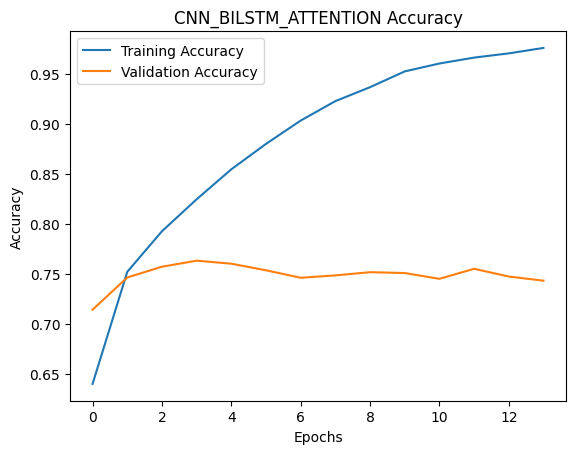

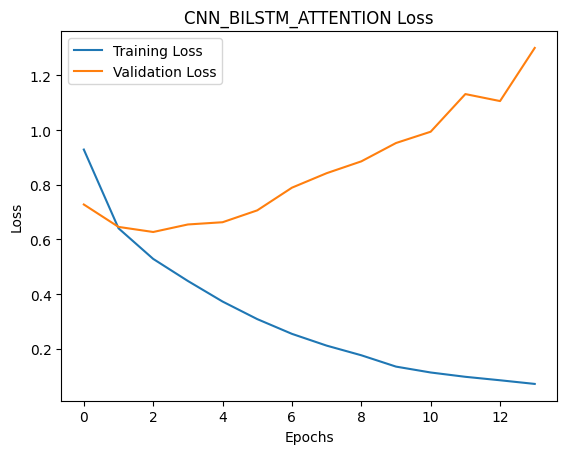

In [ ]:
import matplotlib.pyplot as plt

# ---- Accuracy Plot ----
plt.figure()
plt.plot(train_accs_list, label="Training Accuracy")
plt.plot(val_accs_list, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("CNN_BILSTM_ATTENTION Accuracy")
plt.legend()

plt.savefig("CNN_BILSTM_ATTENTION_ACCCURACY.png", dpi=300, bbox_inches="tight")
plt.show()


# ---- Loss Plot ----
plt.figure()
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("CNN_BILSTM_ATTENTION Loss")
plt.legend()

plt.savefig("CNN_BILSTM_ATTENTION_LOSS.png", dpi=300, bbox_inches="tight")
plt.show()

✅ Successfully loaded weights for CNN_BiLSTM_Attention from best_model.pth


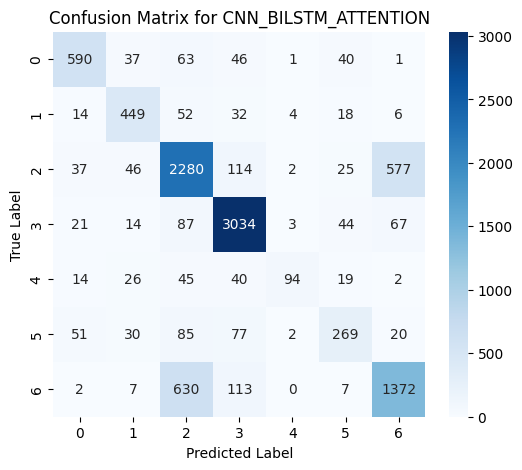

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from transformers import BertTokenizer
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Re-define model architecture (copied from zEZN47NhZ6Ur) to ensure correct model is used
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super(Attention, self).__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, lstm_output):
        attn_weights = self.attn(lstm_output)
        attn_weights = torch.softmax(attn_weights, dim=1)
        context = torch.sum(attn_weights * lstm_output, dim=1)
        return context, attn_weights

class CNN_BiLSTM_Attention(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.conv = nn.Conv1d(embed_dim, 128, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.lstm = nn.LSTM(128, 128, bidirectional=True, batch_first=True)
        self.attention = Attention(256)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, input_ids, attention_mask=None):
        x = self.embedding(input_ids)
        x = x.permute(0, 2, 1)
        x = self.conv(x)
        x = self.relu(x)
        x = self.pool(x)
        x = x.permute(0, 2, 1)
        lstm_out, _ = self.lstm(x)
        attn_out, weights = self.attention(lstm_out)
        out = self.dropout(attn_out)
        return self.fc(out)

# Initialize model for evaluation, ensuring it's the CNN_BiLSTM_Attention type
vocab_size = tokenizer.vocab_size
embed_dim = 300
num_classes = len(df['label'].unique())

model_eval = CNN_BiLSTM_Attention(vocab_size, embed_dim, num_classes)
model_eval.to(device)

# Load the saved best weights (assuming best_model.pth now contains CNN_BiLSTM_Attention weights)
try:
    model_eval.load_state_dict(torch.load("best_model.pth", map_location=device))
    print("✅ Successfully loaded weights for CNN_BiLSTM_Attention from best_model.pth")
except FileNotFoundError:
    print("❌ Error: best_model.pth not found. Please ensure the CNN_BiLSTM_Attention model was trained and saved.")
    raise FileNotFoundError("Model weights 'best_model.pth' not found. Cannot evaluate.")

model_eval.eval() # Set model to evaluation mode
all_preds, all_true = [], []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device) # Only labels needed for true values

        # Call the model_eval with input_ids and None for attention_mask
        outputs = model_eval(input_ids, None)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.cpu().numpy())

cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for CNN_BILSTM_ATTENTION")
plt.savefig("confusion_matrix_CNN_BILSTM.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['status'])

# Save class names in correct order
class_names = le.classes_.tolist()
class_names

['Anxiety',
 'Bipolar',
 'Depression',
 'Normal',
 'Personality disorder',
 'Stress',
 'Suicidal']

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    all_true,
    all_preds,
    target_names=class_names,
    digits=4,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

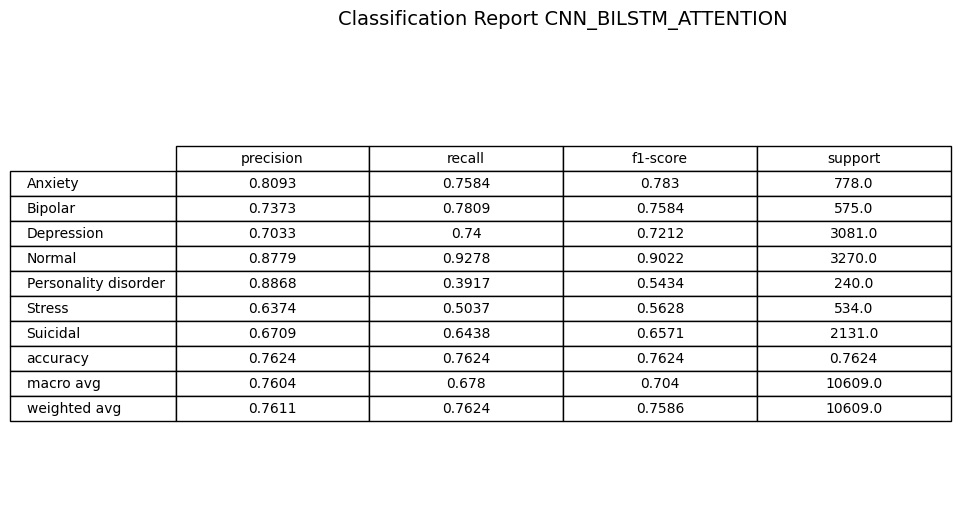

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.axis('off')

table = plt.table(
    cellText=report_df.round(4).values,
    colLabels=report_df.columns,
    rowLabels=report_df.index,
    loc='center',
    cellLoc='center'
)

table.scale(1, 1.5)

plt.title("Classification Report CNN_BILSTM_ATTENTION", fontsize=14, pad=20)

plt.savefig("classification_report_CNN_BILSTM.png", dpi=300, bbox_inches='tight')
plt.show()